<a href="https://colab.research.google.com/github/LuanLindolfo/machinelearning/blob/Linguagem_Natural/Linguagem_Natural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de linguagem natural com Python

## Importação das bibliotecas

In [2]:
import bs4 as bs #beatiful soup -> leitura e processamento de dados na web
import urllib.request #requisição na internet
import nltk
import spacy

In [3]:
!python3 -m spacy download pt
#spacy em português

⚠ As of spaCy v3.0, shortcuts like 'pt' are deprecated. Please use the
full pipeline package name 'pt_core_news_sm' instead.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 81.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


## Marcação POS

- POS (part-of-speech) atribui para as palavras partes da fala, como substantivos, adjetivos, verbos
- Importante para a detecção de entidades no texto, pois primeiro é necessário saber o que o texto contém
- Lista de tokens: https://spacy.io/api/annotation#pos-tagging
- Português: https://www.sketchengine.eu/portuguese-freeling-part-of-speech-tagset/

In [ ]:
# ATUALIZAÇÃO DEZ-2024
# pln = spacy.load('pt')
pln = spacy.load('pt_core_news_sm')
#carregando o modelo do spacy
pln

In [ ]:
documento = pln('Estou aprendendo processamento de linguagem natural, curso em Curitiba')
#criando um documento, texto quaquer -> tem que estar dentro de um objeto

In [ ]:
type(documento)

spacy.tokens.doc.Doc

In [ ]:
for token in documento:
  #for token -> para cada uma das palavras
  print(token.text, token.pos_)
  #token.text -> cada palavra do texto
  #token.pos_ -> marcação POS (esrita acima) -> atribui para as palavras partes da fala, como substantivos, adjetivos, verbos
  #No link fala o que é cada elemento/TAG

Estou AUX
aprendendo VERB
processamento NOUN
de ADP
linguagem NOUN
natural ADJ
, PUNCT
curso NOUN
em ADP
Curitiba PROPN


## Lematização e stemização

In [ ]:
#Lematização

for token in documento:
  #for token -> para cada uma das palavras
  print(token.text, token.lemma_)
  #token.text -> cada palavra do texto
  #token.lemma_ -> indicando o lema de cada uma das palavras (como se fosse o radical)

Estou estar
aprendendo aprender
processamento processamento
de de
linguagem linguagem
natural natural
, ,
curso curso
em em
Curitiba Curitiba


In [ ]:
#lematização -> extrai o radical das palavras
doc = pln('encontrei encontraram encontrarão encontrariam cursando curso cursei')
[token.lemma_ for token in doc]

['encontrar',
 'encontrar',
 'encontrar',
 'encontrariar',
 'cursar',
 'curso',
 'cursar']

In [ ]:
#Stemização

#instalado o stemmer
import nltk
nltk.download('rslp')

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [ ]:
stemmer = nltk.stem.RSLPStemmer()
#RSLPStemmer() - stemmer instalado, extrai o radical em português
stemmer.stem('aprender')

'aprend'

In [ ]:
for token in documento:
  print(token.text, token.lemma_, stemmer.stem(token.text))
  #token.text -> palavra original
  #token.lemma_ -> usando lematização
  #stemmer.stem(token.text) -> usando stemização
  #Nem sempre é tão correto
  #Na mioria dos casos, é melhor usar a lematização

Estou estar est
aprendendo aprender aprend
processamento processamento process
de de de
linguagem linguagem lingu
natural natural natur
, , ,
curso curso curs
em em em
Curitiba Curitiba curitib


## Carregamento dos textos

In [12]:
#acessando um artigo na wikipedia
dados = urllib.request.urlopen('https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial')
#urllib.request.urlopen -> abertura de um link na wikipedia

In [13]:
#'https://pt.wikipedia.org/wiki/Intelig%C3%AAncia_artificial'

In [14]:
#dados = urllib.request.urlopen('https://pt.wikipedia.org/wiki/Inteligência_artificial')

In [15]:
#lendo os dados e printando
dados = dados.read()
dados

b'<!DOCTYPE html>\n<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" lang="pt" dir="ltr">\n<head>\n<meta charset="UTF-8">\n<title>Intelig\xc3\xaancia artificial \xe2\x80\x93 Wikip\xc3\xa9dia, a enciclop\xc3\xa9dia livre</title>\n<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width

In [16]:
#código de leitura em html - tem muitas tags
dados_html = bs.BeautifulSoup(dados, 'lxml')
#lxml - leitura dos arquivos desse dados (pra html ou xml)
dados_html

<!DOCTYPE html>
<html class="client-nojs vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-width-content-enabled vector-feature-custom-font-size-clientpref-1 vector-feature-appearance-pinned-clientpref-1 vector-feature-night-mode-enabled skin-theme-clientpref-day vector-sticky-header-enabled vector-toc-available" dir="ltr" lang="pt">
<head>
<meta charset="utf-8"/>
<title>Inteligência artificial – Wikipédia, a enciclopédia livre</title>
<script>(function(){var className="client-js vector-feature-language-in-header-enabled vector-feature-language-in-main-page-header-disabled vector-feature-page-tools-pinned-disabled vector-feature-toc-pinned-clientpref-1 vector-feature-main-menu-pinned-disabled vector-feature-limited-width-clientpref-1 vector-feature-limited-w

In [17]:
#textops estão na tag P, então precisa fazer a busca nessa tag
paragrafos = dados_html.find_all('p')
#find_all - para achar uma tag em html
#tag A - para links

In [18]:
len(paragrafos)
#65 parágrafos com conteúdo

78

In [19]:
paragrafos[1]#posição dos paragrafos, mas retornando com as tags

<p>Em 1950, Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano inteligente com perfeição. Turing também esboçou uma proposta de pesquisa para tornar isto possível.
</p>

In [20]:
paragrafos[1].text#posição dos paragrafos, mas não retornando com as tags

'Em 1950, Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento humano inteligente com perfeição. Turing também esboçou uma proposta de pesquisa para tornar isto possível.\n'

In [21]:
conteudo = ''
for p in paragrafos:
  #percorrendo cada um dos paragrafos
  conteudo += p.text
  #concatenando todo o conteudo dos paragrafos

In [22]:
conteudo

'Na informática, a Inteligência Artificial (abreviado IA) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3][4][5][6][7] É o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1] É um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[8] A IA iniciou na década de 1950 com os pesquisadores Alan Turing e Herbert Simon baseado no conceito do filósofo grego Aristóteles.\nEm 1950, Allan Turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento h

In [23]:
conteudo = conteudo.lower()
#deixando em letras minúsculas para que o algoritmo entenda sempre as palavras como iguais (ex: Ele e ele)
conteudo

'na informática, a inteligência artificial (abreviado ia) genericamente é a inteligência, o raciocínio e o aprendizado exibida por máquinas semelhante ao raciocino humano;[1][2] busca desenvolver máquinas autônomas ou sistemas especialistas capazes de simular o pensamento humano e realizar várias tarefas complexas de forma independente.[3][4][5][6][7] é o sistema que permite aos computadores executar funções avançadas, como a capacidade de analisar dados em grande escala e fazer previsões/recomendações;[1] é um campo de pesquisa em ciência da computação que desenvolve e estuda métodos e softwares que permitem que as máquinas percebam seu ambiente e usem o aprendizado e a inteligência para tomar ações que maximizem suas chances de atingir objetivos definidos.[8] a ia iniciou na década de 1950 com os pesquisadores alan turing e herbert simon baseado no conceito do filósofo grego aristóteles.\nem 1950, allan turing escreveu sobre ser possível uma máquina pensar, e imitar o comportamento h

## Buscas em textos com spaCy

In [4]:
# ATUALIZAÇÃO DEZ-2024
# pln = spacy.load('pt')
pln = spacy.load('pt_core_news_sm')
pln

In [5]:
string = 'turing' #string de busca
token_pesquisa = pln(string)

In [8]:
pln.vocab #retorna o endereço de memória e a classe que representa o vocabulário
#.Vocab - classe que representa o vocabulário, ou seja, no modelo PT - Brasil ele tem todas as palavras no vocabulário, da língua portuguesa,
#Assim ele sabe se a palavra é uma preposição, um verbo e afins

In [9]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(pln.vocab)
matcher.add('SEARCH', None, token_pesquisa)#adicionando uma busca
#e o token de pesquisa na busca

In [24]:
doc = pln(conteudo) #buscando no conteúdo do texto
matches = matcher(doc)#vai guardar os resultados nes variável
matches#retorna lista com esses resultados

[(8661325627334373315, 130, 131),
 (8661325627334373315, 147, 148),
 (8661325627334373315, 165, 166),
 (8661325627334373315, 826, 827),
 (8661325627334373315, 835, 836),
 (8661325627334373315, 872, 873),
 (8661325627334373315, 1014, 1015),
 (8661325627334373315, 4269, 4270),
 (8661325627334373315, 4279, 4280),
 (8661325627334373315, 4435, 4436),
 (8661325627334373315, 4440, 4441),
 (8661325627334373315, 4446, 4447),
 (8661325627334373315, 4509, 4510),
 (8661325627334373315, 5006, 5007),
 (8661325627334373315, 6370, 6371),
 (8661325627334373315, 6418, 6419),
 (8661325627334373315, 6553, 6554),
 (8661325627334373315, 6648, 6649),
 (8661325627334373315, 6765, 6766)]

In [26]:
doc[2323:2324], doc[2323-5:2324+5]
#na esquerda é o ID da busca
#na direita posição da palavra onde foi encontrado

(de, acontece a partir da década de 2010, com resultados extramemente)

In [28]:
doc[2333:2334], doc[2333-5:2334+5]
#[2333-5:2334+5] - o contexto que a palavra aparece

(década, extramemente fortes no final dessa década e no início da década)

In [30]:
matches[0], matches[0][1], matches[0][2]
#posição inicial e posição final

((8661325627334373315, 130, 131), 130, 131)

In [31]:
from IPython.core.display import HTML #possibilidade de gerar código html
texto = '' #para iniciar o texto vazio e não contatenar com a pesquisa anterior
numero_palavras = 50 #quantas palavras antes e quantas palavras depois
doc = pln(conteudo) #conteudo
matches = matcher(doc) #onde o resultado fica

#Exibindo a palavra que vai pesquisar
#display(HTML(f' - padrão pra código html
display(HTML(f'<h1>{string.upper()}</h1>'))
#<h1> - código html para títulos
#string.upper() - variavel da pesquisa, em letra maiúscula

#display(HTML(f""" - formatação da biblioteca
display(HTML(f"""<p><strong>Resultados encontrados:</strong> {len(matches)}</p>"""))
#<p> - código html para parágrafo
#<strong> - código html para texto em negrito
#{len(matches)} - pega o tamanho da variavel de pesquisas encontradas

#passando por cada matches e ir buscando os textos
for i in matches:
  # - numero_palavras -> pra poder pegar as palavras anteriores
  inicio = i[1] - numero_palavras
  if inicio < 0: #se for 0, não tem texto à esquerda
    inicio = 0
  texto += str(doc[inicio:i[2] + numero_palavras]).replace(string, f"<mark>{string}</mark>")
  #.replace - para substituir um caracter  - string (da pesquisa), f"<mark>{string}</mark>"
  #ou seja, a palavra pesquisa pela palavra pesquisada realçada
  #<mark> - ódigo html para realce no texto
  #documento texto, em string, indo da posição start até a i[2] + numero de palavras
  #(pegando tudo a direita)
  texto += "<br /><br />"
  #<br - código html para pular linhas
  #+= - concatenando os resultados
display(HTML(f"""... {texto} ... """))
#formatação de exibição

## Extração de entidades nomeadas

- NER (Named-Entity Recognition)
- Encontrar e classificar entidades no texto, dependendo da base de dados que foi utilizada para o treinamento (pessoa, localização, empresa, numéricos)
- Usado em chatbots para saber o assunto falado
- Siglas: https://spacy.io/api/annotation#named-entities

In [33]:
for entidade in doc.ents:#.ents - palavra chave que retorna as entidades
  print(entidade.text, entidade.label_)
  #entidade.text - texto original
  #entidade.label_ - nesse atributo que vai ter as entidades
  #tem as simbologias que ele faz as definições

independente.[3][4][5][6][7 MISC
alan turing PER
herbert simon PER
aristóteles PER
allan turing PER
turing PER
google search MISC
youtube MISC
amazon ORG
netflix PER
google assistant MISC
siri PER
waymo PER
go LOC
história,[14 MISC
aristóteles PER
alexandre PER
allan turing PER
herbert simon PER
john mccarthy PER
turing PER
computing machinery and inteiligence MISC
humano.[18 MISC
possível.[18 PER
herbert simon PER
allen newell PER
turing PER
herbert simon PER
allen newell PER
the simulation of human thought MISC
brasil LOC
allen newell PER
herbert simon PER
marvin minsky PER
mit ORG
lab MISC
darthmouth LOC
defense advanced research MISC
estados unidos LOC
fifth generation MISC
” MISC
japão LOC
prolog MISC
neurônios,[25 ORG
aleatórios.[26 ORG
google ORG
wikipédia MISC
john mccarthy PER
andreas kaplan PER
michael haenlein PER
john mccarthy PER
román LOC
john haugeland PER
w. grey walter PER
johns hopkins PER
universidade de princeton ORG
ratio club LOC
inglaterra LOC
david rumelhart PER

In [34]:
from spacy import displacy
displacy.render(doc, style = 'ent', jupyter = True)
#mostrando as entidades no texto com uma melhor renderização pra visualização

## Nuvem de palavras e stop words

In [40]:
#Nuvem de palavras é pra analisar os termos mais frequentes de um documento
#tirando as stop words (de, que, se...)
from spacy.lang.pt.stop_words import STOP_WORDS
print(STOP_WORDS)

{'tenho', 'adeus', 'como', 'estou', 'des', 'na', 'toda', 'por', 'estado', 'debaixo', 'ambas', 'deverá', 'terceiro', 'tente', 'deve', 'aquelas', 'fazem', 'quê', 'fomos', 'lhe', 'número', 'aqui', 'meus', 'tuas', 'primeiro', 'caminho', 'cá', 'diante', 'povo', 'questão', 'ir', 'bom', 'faço', 'dez', 'é', 'pelas', 'foste', 'final', 'números', 'vem', 'isto', 'inicio', 'talvez', 'quem', 'possível', 'está', 'estão', 'disso', 'nessa', 'ligado', 'estive', 'seis', 'atrás', 'nesta', 'área', 'segundo', 'esses', 'para', 'novo', 'obrigada', 'sempre', 'sob', 'estivestes', 'grandes', 'seus', 'dentro', 'apoio', 'nova', 'quarta', 'nunca', 'têm', 'faz', 'devem', 'mal', 'foi', 'ambos', 'tentaram', 'tanto', 'dão', 'nossos', 'vossa', 'algumas', 'comprido', 'pois', 'assim', 'nós', 'oitavo', 'longe', 'que', 'essas', 'a', 'tens', 'foram', 'tais', 'mesmo', 'dar', 'cujo', 'relação', 'mas', 'apoia', 'vinda', 'vossos', 'cuja', 'obrigado', 'conselho', 'nenhuma', 'exemplo', 'usa', 'das', 'segunda', 'sexta', 'próximo',

In [41]:
len(STOP_WORDS) #quantidade de stop words (que vão ser removidas)

416

In [42]:
pln.vocab['usa'].is_stop #perguntando se é stop word ou não

True

In [43]:
doc = pln(conteudo) #convertendo pro formato do space
lista_token = [] #lista vazia
for token in doc:
  lista_token.append(token.text)#adicionando cada um dos tokens na lista

In [44]:
print(lista_token)

['na', 'informática', ',', 'a', 'inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'é', 'a', 'inteligência', ',', 'o', 'raciocínio', 'e', 'o', 'aprendizado', 'exibida', 'por', 'máquinas', 'semelhante', 'ao', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'ou', 'sistemas', 'especialistas', 'capazes', 'de', 'simular', 'o', 'pensamento', 'humano', 'e', 'realizar', 'várias', 'tarefas', 'complexas', 'de', 'forma', 'independente.[3][4][5][6][7', ']', 'é', 'o', 'sistema', 'que', 'permite', 'aos', 'computadores', 'executar', 'funções', 'avançadas', ',', 'como', 'a', 'capacidade', 'de', 'analisar', 'dados', 'em', 'grande', 'escala', 'e', 'fazer', 'previsões', '/', 'recomendações;[1', ']', 'é', 'um', 'campo', 'de', 'pesquisa', 'em', 'ciência', 'da', 'computação', 'que', 'desenvolve', 'e', 'estuda', 'métodos', 'e', 'softwares', 'que', 'permitem', 'que', 'as', 'máquinas', 'percebam', 'seu', 'ambiente', 'e', 'usem', 'o', 'aprendizado', 'e

In [47]:
len(lista_token)#tamanho da lista com as stops words

7161

In [48]:
sem_stop = [] #lista vazia para armazenar as não stopwords
for palavra in lista_token:#percorrendo cada palavra e vendo se é stopword pra eliminar
  if pln.vocab[palavra].is_stop == False:#se não for stop
    sem_stop.append(palavra)#adiciona na lista

In [49]:
print(sem_stop)

['informática', ',', 'inteligência', 'artificial', '(', 'abreviado', 'ia', ')', 'genericamente', 'inteligência', ',', 'raciocínio', 'aprendizado', 'exibida', 'máquinas', 'semelhante', 'raciocino', 'humano;[1][2', ']', 'busca', 'desenvolver', 'máquinas', 'autônomas', 'sistemas', 'especialistas', 'capazes', 'simular', 'pensamento', 'humano', 'realizar', 'várias', 'tarefas', 'complexas', 'independente.[3][4][5][6][7', ']', 'permite', 'computadores', 'executar', 'funções', 'avançadas', ',', 'capacidade', 'analisar', 'dados', 'escala', 'previsões', '/', 'recomendações;[1', ']', 'campo', 'pesquisa', 'ciência', 'computação', 'desenvolve', 'estuda', 'métodos', 'softwares', 'permitem', 'máquinas', 'percebam', 'ambiente', 'usem', 'aprendizado', 'inteligência', 'tomar', 'ações', 'maximizem', 'chances', 'atingir', 'objetivos', 'definidos.[8', ']', 'ia', 'iniciou', 'década', '1950', 'pesquisadores', 'alan', 'turing', 'herbert', 'simon', 'baseado', 'conceito', 'filósofo', 'grego', 'aristóteles', '.'

In [51]:
len(sem_stop)#tamanho da lista sem as stops words

4154

In [52]:
from matplotlib.colors import ListedColormap
#ListedColormap - definindo as cores exibidas na nossa nuvem de palavras
color_map = ListedColormap(['orange', 'green', 'red', 'magenta']) #definição das cores em formato de lista

In [53]:
from wordcloud import WordCloud #pra gerar a nuvem de palavras
cloud = WordCloud(background_color = 'white', max_words = 100, colormap=color_map)
#cor de fundo, numero maximo de palavras e as cores no color map

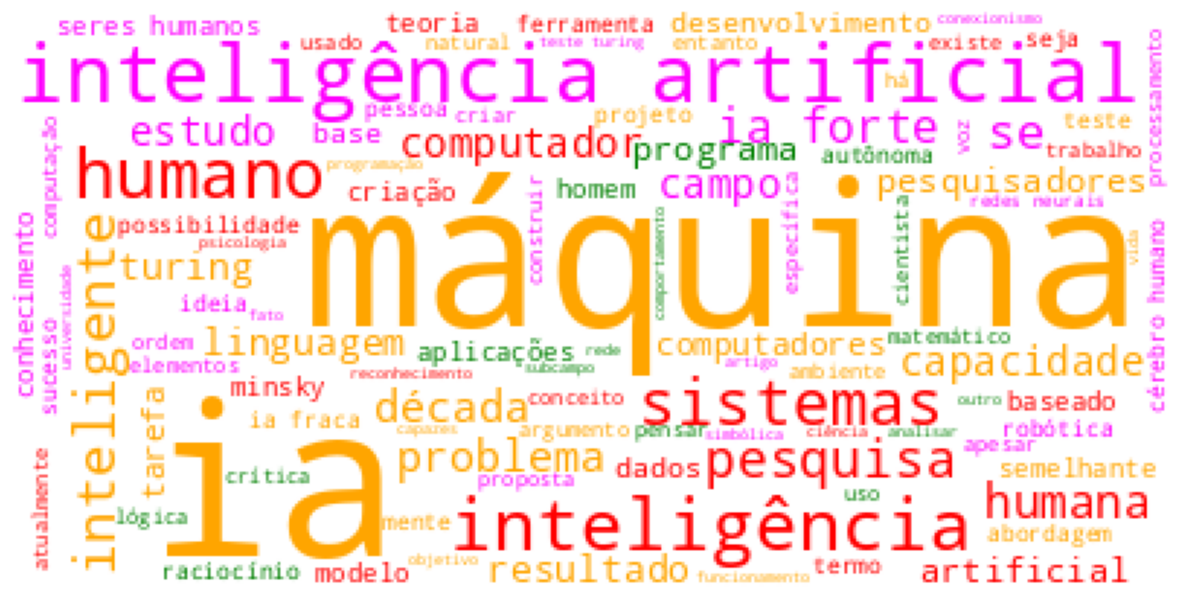

In [54]:
import matplotlib.pyplot as plt#pra geração de gráfico
cloud = cloud.generate(' '.join(sem_stop))
#cloud.generate(conteúdo)- vai gerar uma nuvem de palavras
plt.figure(figsize=(15,15))#tamanho
plt.imshow(cloud)#pra mostrar
plt.axis('off')#desligando a visualização do eixo x e do eixo y
plt.show()

#cloud.generate(conteúdo) - vai gerar muitas stopwords (de, que, se...)
#e a nuvem de palavras não vai ser relevante